In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

B, T, D, H, V = 2, 128, 128, 4, 50257

F_block = 24 * B * T * D**2 + 4 * B * T**2 * D
F_head = 2 * B * T * D * V

accounting = pd.DataFrame({"L": [1, 2, 4, 8, 12, 16]})

accounting["block_flops"] = accounting["L"] * F_block
accounting["head_flops"] = F_head
accounting["forward_flops"] = accounting["block_flops"] + F_head
accounting["forward_gflops"] = accounting["forward_flops"] / 1e9
accounting["block_fraction"] = (
    accounting["block_flops"] / accounting["forward_flops"]
)
accounting["relative_to_L2"] = (
    accounting["forward_flops"] / (2 * F_block + F_head)
)

accounting

,L,block_flops,head_flops,forward_flops,forward_gflops,block_fraction,relative_to_L2
0,1,117440512,3293642752,3411083264,3.411083,0.034429,0.966717
1,2,234881024,3293642752,3528523776,3.528524,0.066566,1.000000
2,4,469762048,3293642752,3763404800,3.763405,0.124824,1.066566
3,8,939524096,3293642752,4233166848,4.233167,0.221944,1.199699
4,12,1409286144,3293642752,4702928896,4.702929,0.299661,1.332832
5,16,1879048192,3293642752,5172690944,5.172691,0.363263,1.465965


In [2]:
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    if root == root.parent:
        raise FileNotFoundError("Run this notebook from inside the repository.")
    root = root.parent

results_dir = root / "experiments/01_depth_scaling/results"
groups = {"Baseline": "check-*", "Autograd on": "grad-check-*", "Autograd off": "no-grad-check-*"}
runs, rows = {}, []

for group, pattern in groups.items():
    runs[group] = {}
    for path in sorted(results_dir.glob(f"{pattern}/l2.json")):
        with path.open() as file:
            result = json.load(file)
        runs[group][path.parent.name] = result
        for workload, measurement in result["measurements"].items():
            rows.append({
                "group": group, "run": path.parent.name, "workload": workload,
                "mean_ms": measurement["mean_seconds"] * 1000,
                "median_ms": measurement["median_seconds"] * 1000,
                "max_ms": max(measurement["samples_seconds"]) * 1000,
            })

configs = [r["config"] for group in runs.values() for r in group.values()]
assert all(config == configs[0] for config in configs)

timings = pd.DataFrame(rows)
timings.round(2)

,group,run,workload,mean_ms,median_ms,max_ms
0,Baseline,check-01,forward,15.55,16.27,24.67
1,Baseline,check-01,forward_backward,28.39,28.35,37.52
2,Baseline,check-01,optimizer_step,36.43,36.51,49.17
3,Baseline,check-02,forward,17.48,17.70,25.35
4,Baseline,check-02,forward_backward,28.51,28.50,34.55
5,Baseline,check-02,optimizer_step,36.51,36.54,51.52
6,Baseline,check-03,forward,16.31,16.95,23.35
7,Baseline,check-03,forward_backward,28.43,28.39,41.43
8,Baseline,check-03,optimizer_step,36.50,36.58,49.40
9,Autograd on,grad-check-01,forward,18.87,17.52,170.28


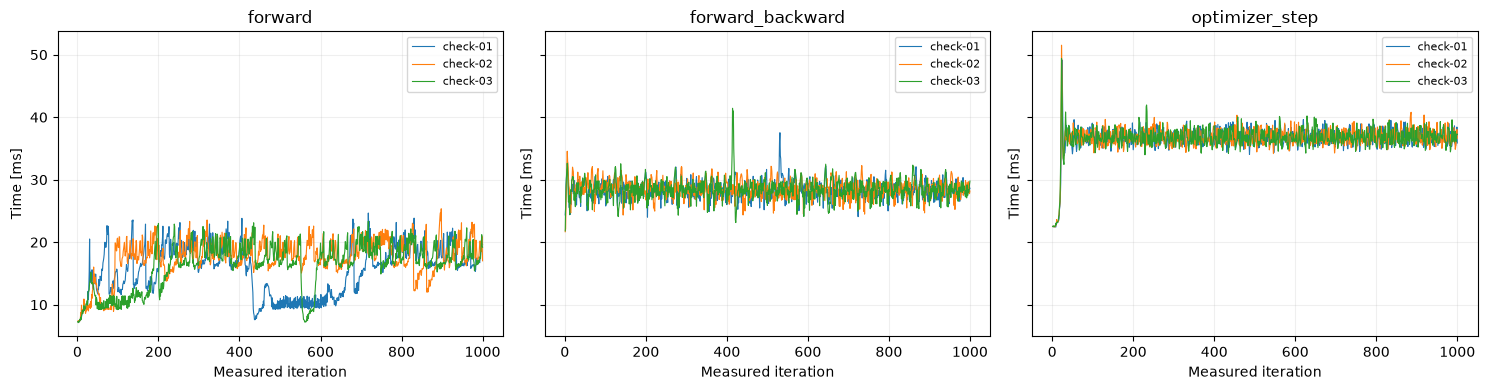

In [3]:
workloads = ["forward", "forward_backward", "optimizer_step"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, workload in zip(axes, workloads):
    for name, result in runs["Baseline"].items():
        ms = [s * 1000 for s in result["measurements"][workload]["samples_seconds"]]
        ax.plot(range(1, len(ms) + 1), ms, label=name, linewidth=0.8)
    ax.set_title(workload)
    ax.set_xlabel("Measured iteration")
    ax.set_ylabel("Time [ms]")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

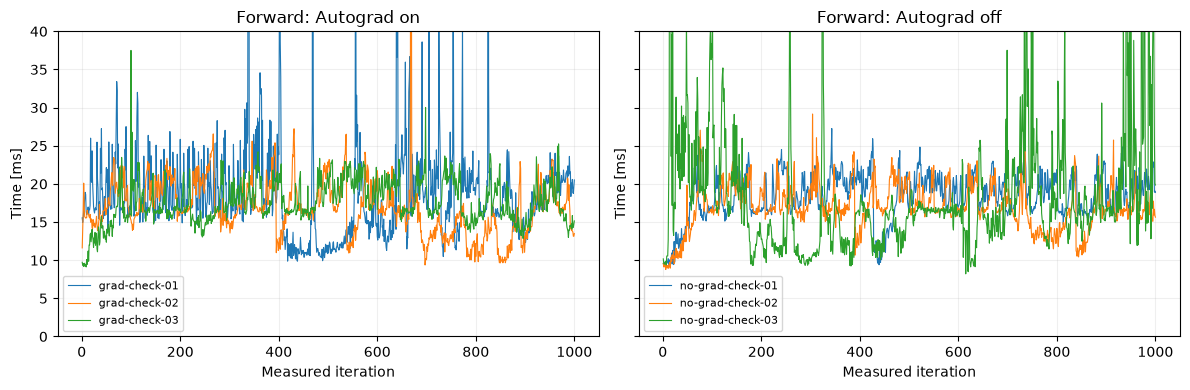

In [4]:
zoom = True  # False shows all spikes.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, group in zip(axes, ["Autograd on", "Autograd off"]):
    outside = 0
    for name, result in runs[group].items():
        ms = [s * 1000 for s in result["measurements"]["forward"]["samples_seconds"]]
        ax.plot(range(1, len(ms) + 1), ms, label=name, linewidth=0.8)
        outside += sum(value > 30 for value in ms)
    ax.set_title(f"Forward: {group}")
    ax.set_xlabel("Measured iteration")
    ax.set_ylabel("Time [ms]")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
    if zoom:
        ax.set_ylim(0, 40)

plt.tight_layout()
plt.show()

## Memory across steps

For a tensor, storage is the number of elements times bytes per element. FP32 uses 4 bytes; int64 token IDs use 8.

$$
M_{\text{weights}}=4N,\qquad M_{\text{gradients}}\approx4N,\qquad
M_{\text{Adam states}}\approx8N
$$

$$
M_{\text{logits}}=4BTV,\qquad
M_{\text{weights+gradients+Adam}}\approx16N
$$

N counts shared embedding/head weights only once. These are tensor payload sizes, not total device memory: buffers, saved activations, loss intermediates and allocator overhead also matter. Do not count logits twice if they are already included in another category.

- **tensor_MiB**: memory currently occupied by MPS tensors, excluding unused allocator cache.
- **driver_MiB**: process GPU allocations, including allocator caches and Metal framework allocations. It is not extra memory to add to tensor_MiB.
- MiB = bytes / 2^{20}. Neither counter is total Mac RAM or an instantaneous peak.

We reuse the same model and batch for 1000 steps. Gradients are cleared before each forward. AdamW is created only for optimizer_step; its moment tensors first appear during the first update.

**before_forward** includes inputs and any existing optimizer state, but no previous gradients.
**after_forward** keeps logits/loss and, with autograd, saved tensors for backward.
**after_backward** includes gradients; many saved tensors have been released.
**after_optimizer_step** also includes AdamW states.
**after_release** drops logits/loss; gradients remain until the next step.

Each snapshot synchronizes the device. This changes execution: these separate runs inspect memory, not latency. No warmup is discarded and no allocator cache is manually cleared.

Sources: [tensor counter](https://docs.pytorch.org/docs/2.14/generated/torch.mps.current_allocated_memory.html), [driver counter](https://docs.pytorch.org/docs/2.14/generated/torch.mps.driver_allocated_memory.html).

In [5]:
memory_rows = []
memory_runs = {}
for path in sorted((results_dir / "memory-history").glob("*.json")):
    with path.open() as file:
        result = json.load(file)
    memory_runs[path.stem] = result
    for snapshot in result["snapshots"]:
        memory_rows.append({
            "workload": path.stem, "step": snapshot["step"], "stage": snapshot["stage"],
            "tensor_MiB": snapshot["tensor_bytes"] / 2**20,
            "driver_MiB": snapshot["driver_bytes"] / 2**20,
        })

memory = pd.DataFrame(memory_rows)
memory[memory["step"] > 0].groupby(["workload", "stage"], sort=False)[
    ["tensor_MiB", "driver_MiB"]
].agg(["first", "last", "min", "max"]).round(2)

tensor_MiB                          \
                                           first    last     min     max   
workload         stage                                                     
forward-no-grad  before_forward            27.14   27.14   27.14   27.14   
                 after_forward             77.14   77.14   77.14   77.14   
                 after_release             27.14   27.14   27.14   27.14   
forward          before_forward            27.14   27.14   27.14   27.14   
                 after_forward            132.44  132.44  132.44  132.44   
                 after_release             27.14   27.14   27.14   27.14   
forward_backward before_forward            27.14   27.14   27.14   27.14   
                 after_forward            132.44  132.44  132.44  132.44   
                 after_backward           103.78  103.78  103.78  103.78   
                 after_release             53.78   53.78   53.78   53.78   
optimizer_step   before_forward            27.14   80.42   27.14   80.42   
                 after_forward            132.44  185.71  132.44  185.71   
                 after_backward           103.78  157.06  103.78  157.06   
                 after_optimizer_step     157.06  157.06  157.06  157.06   
                 after_release            107.06  107.06  107.06  107.06   

                                      driver_MiB                            
                                           first    last      min      max  
workload         stage                                                      
forward-no-grad  before_forward          1032.47  1034.7  1032.47  1034.72  
                 after_forward           1034.72  1034.7  1034.70  1034.72  
                 after_release           1034.72  1034.7  1034.70  1034.72  
forward          before_forward          1032.47  1034.7  1032.47  1034.72  
                 after_forward           1034.72  1034.7  1034.70  1034.72  
                 after_release           1034.72  1034.7  1034.70  1034.72  
forward_backward before_forward          1032.47  1092.8  1032.47  1092.81  
                 after_forward           1034.72  1092.8  1034.72  1092.81  
                 after_backward          1092.81  1092.8  1092.80  1092.81  
                 after_release           1092.81  1092.8  1092.80  1092.81  
optimizer_step   before_forward          1032.47  1100.8  1032.47  1100.80  
                 after_forward           1034.70  1100.8  1034.70  1100.80  
                 after_backward          1092.80  1100.8  1092.80  1100.80  
                 after_optimizer_step    1100.80  1100.8  1100.80  1100.80  
                 after_release           1100.80  1100.8  1100.80  1100.80

In [6]:
result = memory_runs["optimizer_step"]
N = result["parameter_count"]
c = result["config"]
B, T, V = c["batch_size"], c["sequence_length"], c["model"]["vocab_size"]

payloads = pd.DataFrame({
    "part": ["Weights", "Gradients", "Two Adam moments", "Logits", "Model buffers"],
    "bytes": [4 * N, 4 * N, 8 * N, 4 * B * T * V, result["buffer_bytes"]],
})
payloads["MiB"] = payloads["bytes"] / 2**20
payloads.round(2)

,part,bytes,MiB
0,Weights,27449856,26.18
1,Gradients,27449856,26.18
2,Two Adam moments,54899712,52.36
3,Logits,51463168,49.08
4,Model buffers,524288,0.50


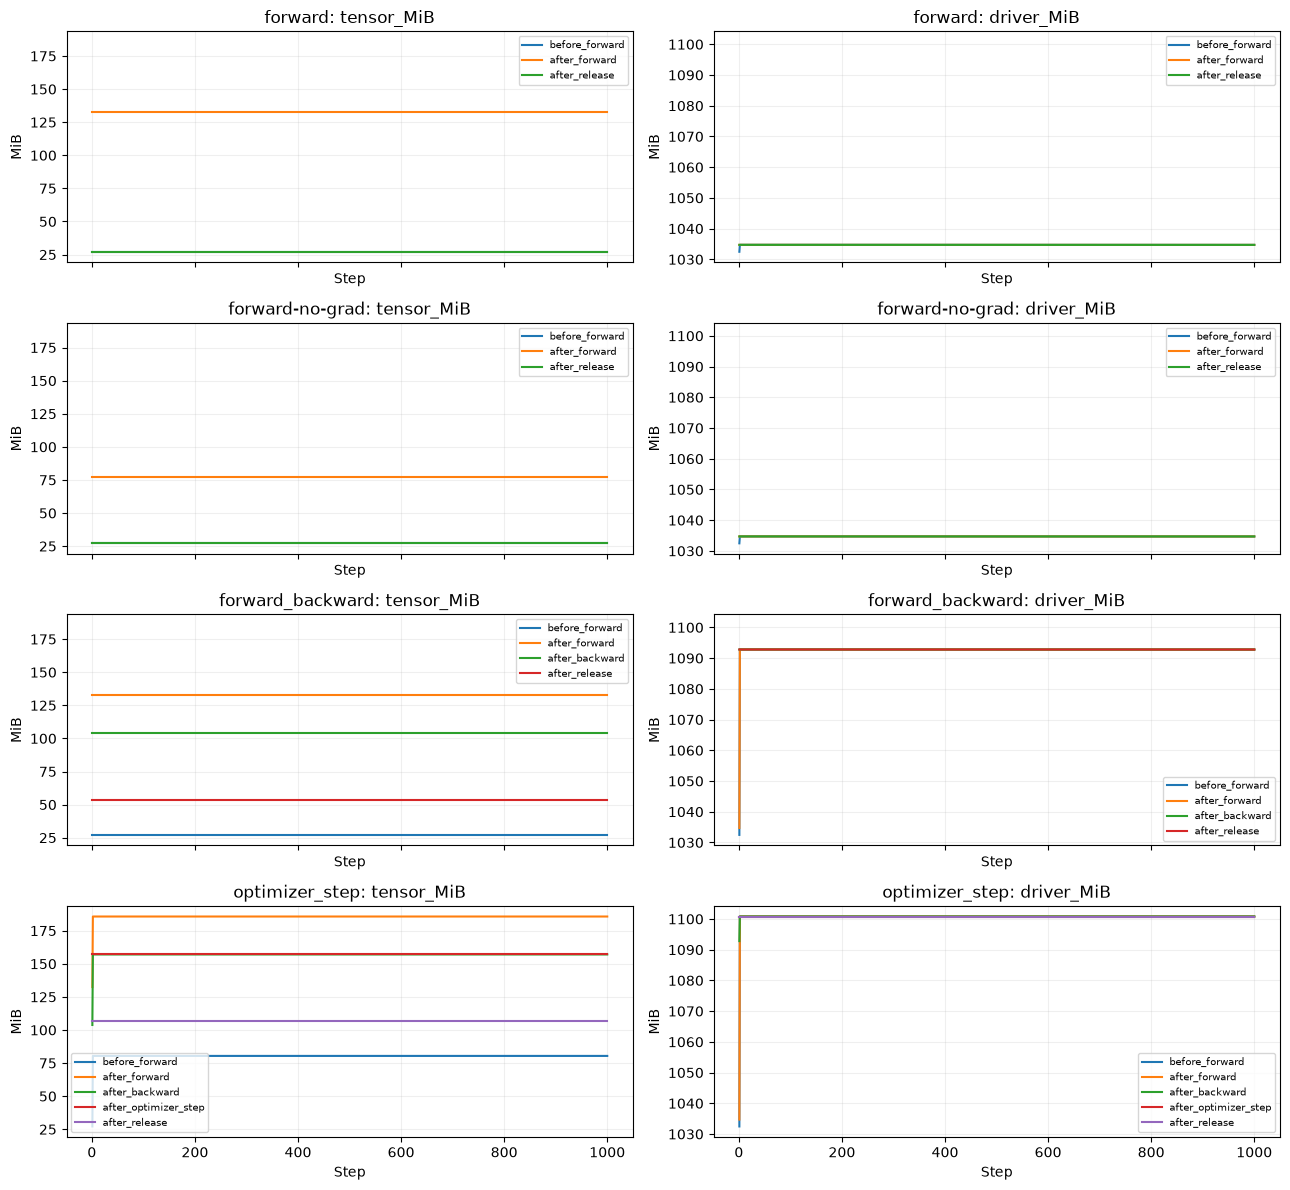

In [7]:
last_step = 1000  # Set 20 to inspect the first steps.
names = ["forward", "forward-no-grad", "forward_backward", "optimizer_step"]
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True, sharey="col")

for row, name in enumerate(names):
    data = memory[(memory["workload"] == name) & (memory["step"] > 0)]
    data = data[data["step"] <= last_step]
    for col, metric in enumerate(["tensor_MiB", "driver_MiB"]):
        ax = axes[row, col]
        for stage, points in data.groupby("stage", sort=False):
            ax.plot(points["step"], points[metric], label=stage)
        ax.set_title(f"{name}: {metric}")
        ax.set_xlabel("Step")
        ax.set_ylabel("MiB")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()